# 실습 5-3 : Trace Data 처리

#### **<실습 내용>**

1. Trace Data의 구조 이해

2. 데이터 전처리

3. Trace Data → 머신러닝 입력 데이터 변환
- 요약 통계량 (Summary Statistics) 후보
- 전체 구간 요약 (Simple Summary)
- 구간별 요약 (Step-based Summary)

## 분석 준비

### 주요 라이브러리 호출

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"   # Windows 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 기호 깨짐 방지

from sklearn.preprocessing import MinMaxScaler

### 데이터 불러오기

In [2]:
data = pd.read_csv("dataset/day5-3_data.csv", index_col=0)
print("데이터 크기:", data.shape)
data.head()

데이터 크기: (15480, 20)


,Step Number,BCl3 Flow,Cl2 Flow,RF Btm Pwr,RF Btm Rfl Pwr,Endpt A,He Press,Pressure,RF Tuner,RF Load,RF Phase Err,RF Pwr,RF Impedance,TCP Tuner,TCP Phase Err,TCP Impedance,TCP Top Pwr,TCP Rfl Pwr,TCP Load,Vat Valve
0,4.0,751.0,753.000000,132.000000,0.0,626.000000,100.000000,1227.000000,9408.000000,9019.000000,-362.000000,26.000000,16599.00000,20028.00000,-296.000000,16848.00000,360.000000,0.0,27594.00000,49.000000
0,4.0,751.0,753.000000,133.865546,0.0,620.403361,99.067227,1228.865546,9429.453782,9028.327731,-1381.521008,26.000000,16570.08403,20041.05882,-650.453781,16799.49580,350.672269,0.0,27450.35294,49.000000
0,4.0,751.0,754.731092,134.000000,0.0,601.823529,101.596639,1222.075630,9394.647059,9102.571429,-1109.647059,25.134454,16458.94118,20132.01681,-342.764706,16550.18487,344.806723,0.0,27298.05042,49.000000
0,4.0,751.0,753.403361,133.201681,0.0,588.621849,100.403361,1205.033613,9433.705882,9047.739496,-681.588235,25.000000,16855.52941,20147.59664,-267.848740,16917.54622,350.386555,0.0,27319.10924,49.798319
0,4.0,751.0,753.731092,132.268908,0.0,586.731092,101.462185,1187.109244,9453.042017,9039.773109,-248.504202,25.000000,16670.48739,20205.02521,-470.361344,16595.96639,347.613445,0.0,27280.28571,50.000000


In [3]:
data.tail()

,Step Number,BCl3 Flow,Cl2 Flow,RF Btm Pwr,RF Btm Rfl Pwr,Endpt A,He Press,Pressure,RF Tuner,RF Load,RF Phase Err,RF Pwr,RF Impedance,TCP Tuner,TCP Phase Err,TCP Impedance,TCP Top Pwr,TCP Rfl Pwr,TCP Load,Vat Valve
128,5.0,751.226891,753.226891,131.680672,0.000000,594.319328,101.546218,1227.000000,9367.378151,8886.117647,1243.840336,26.000000,16283.21008,18851.73109,-327.117647,16464.92437,342.989864,0.000000,28398.36975,51.0
128,5.0,751.579832,752.420168,132.739496,0.000000,592.680672,101.420168,1227.000000,9354.798319,8904.319328,1330.941176,26.579832,16241.53782,18888.78992,121.445378,16491.39496,350.653729,0.000000,28354.95798,51.0
128,5.0,752.000000,752.773109,134.386555,0.386555,591.000000,101.000000,1226.226891,9392.243697,8877.008403,826.369748,26.613445,16402.91597,18931.78151,518.302521,16550.38655,354.603309,0.000000,28343.76471,51.0
128,5.0,752.000000,753.806723,135.000000,0.806723,591.579832,100.806723,1225.386555,9427.411765,8839.890756,297.428571,26.000000,16576.21849,18962.70588,553.310924,16583.79832,351.729360,0.193277,28324.18487,51.0
128,5.0,752.000000,753.000000,135.000000,0.000000,594.000000,100.000000,1227.000000,9354.000000,8877.000000,750.000000,26.000000,16598.00000,18974.00000,300.000000,16416.00000,352.536083,1.000000,28350.00000,51.0


---

## 1) Trace Data의 구조 이해

- 129개의 웨이퍼에 대해 공정 진행 과정에서 120개의 측정 포인트마다 19개의 센서 값을 기록한 데이터임
- 데이터는 (129, 120, 19) 형태의 3차원 Trace Data로 구성됨

In [4]:
# 제품(웨이퍼) 수 확인

print("제품 수:", len(data.index.unique()))  # index 고유값 수 = 고유 제품(웨이퍼) 수
print("변수 수:", data.shape[1])              # 전체 컬럼(feature) 개수

제품 수: 129
변수 수: 20


In [5]:
# 0번 웨이퍼의 데이터 확인
print("0번 웨이퍼 데이터 크기:", data.loc[0].shape)  # index가 0인 행(들)의 shape 확인
data.loc[0]  # index가 0인 데이터 출력

0번 웨이퍼 데이터 크기: (120, 20)


,Step Number,BCl3 Flow,Cl2 Flow,RF Btm Pwr,RF Btm Rfl Pwr,Endpt A,He Press,Pressure,RF Tuner,RF Load,RF Phase Err,RF Pwr,RF Impedance,TCP Tuner,TCP Phase Err,TCP Impedance,TCP Top Pwr,TCP Rfl Pwr,TCP Load,Vat Valve
0,4.000000,751.000000,753.000000,132.000000,0.0,626.000000,100.000000,1227.000000,9408.000000,9019.000000,-362.000000,26.000000,16599.00000,20028.00000,-296.000000,16848.00000,360.000000,0.0,27594.00000,49.000000
0,4.000000,751.000000,753.000000,133.865546,0.0,620.403361,99.067227,1228.865546,9429.453782,9028.327731,-1381.521008,26.000000,16570.08403,20041.05882,-650.453781,16799.49580,350.672269,0.0,27450.35294,49.000000
0,4.000000,751.000000,754.731092,134.000000,0.0,601.823529,101.596639,1222.075630,9394.647059,9102.571429,-1109.647059,25.134454,16458.94118,20132.01681,-342.764706,16550.18487,344.806723,0.0,27298.05042,49.000000
0,4.000000,751.000000,753.403361,133.201681,0.0,588.621849,100.403361,1205.033613,9433.705882,9047.739496,-681.588235,25.000000,16855.52941,20147.59664,-267.848740,16917.54622,350.386555,0.0,27319.10924,49.798319
0,4.000000,751.000000,753.731092,132.268908,0.0,586.731092,101.462185,1187.109244,9453.042017,9039.773109,-248.504202,25.000000,16670.48739,20205.02521,-470.361344,16595.96639,347.613445,0.0,27280.28571,50.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,5.000000,752.000000,754.000000,132.268908,0.0,1023.268908,100.731092,1184.268908,9436.537815,9038.680672,475.537815,21.000000,16913.10924,19295.22689,484.991597,16387.07563,350.731092,0.0,27937.19328,50.000000
0,5.000000,752.000000,753.798319,133.403361,0.0,1023.394958,100.000000,1185.000000,9439.613445,8982.840336,209.016807,21.000000,16994.63866,19305.61345,537.630252,16392.01681,348.991597,0.0,27862.11765,50.000000
0,5.000000,751.865546,753.000000,134.865546,0.0,1020.865546,100.000000,1184.865546,9447.882353,9002.134454,35.319328,20.865546,16856.55462,19312.26891,-16.789916,16400.00000,346.478992,0.0,27919.61345,50.000000
0,4.932773,751.067227,752.932773,133.798319,0.0,994.655462,100.067227,1187.092437,9458.050420,9004.747899,1206.991597,20.336134,16474.57983,19361.73109,-4.630252,16410.21849,355.327731,0.0,27909.56303,49.932773


In [6]:
# 0번부터 128번 웨이퍼까지 각각의 데이터 크기 확인
for i in range(129):  # 0~128번 웨이퍼
    print(f"{i}번 웨이퍼 데이터 크기:", data.loc[i].shape)

0번 웨이퍼 데이터 크기: (120, 20)
1번 웨이퍼 데이터 크기: (120, 20)
2번 웨이퍼 데이터 크기: (120, 20)
3번 웨이퍼 데이터 크기: (120, 20)
4번 웨이퍼 데이터 크기: (120, 20)
5번 웨이퍼 데이터 크기: (120, 20)
6번 웨이퍼 데이터 크기: (120, 20)
7번 웨이퍼 데이터 크기: (120, 20)
8번 웨이퍼 데이터 크기: (120, 20)
9번 웨이퍼 데이터 크기: (120, 20)
10번 웨이퍼 데이터 크기: (120, 20)
11번 웨이퍼 데이터 크기: (120, 20)
12번 웨이퍼 데이터 크기: (120, 20)
13번 웨이퍼 데이터 크기: (120, 20)
14번 웨이퍼 데이터 크기: (120, 20)
15번 웨이퍼 데이터 크기: (120, 20)
16번 웨이퍼 데이터 크기: (120, 20)
17번 웨이퍼 데이터 크기: (120, 20)
18번 웨이퍼 데이터 크기: (120, 20)
19번 웨이퍼 데이터 크기: (120, 20)
20번 웨이퍼 데이터 크기: (120, 20)
21번 웨이퍼 데이터 크기: (120, 20)
22번 웨이퍼 데이터 크기: (120, 20)
23번 웨이퍼 데이터 크기: (120, 20)
24번 웨이퍼 데이터 크기: (120, 20)
25번 웨이퍼 데이터 크기: (120, 20)
26번 웨이퍼 데이터 크기: (120, 20)
27번 웨이퍼 데이터 크기: (120, 20)
28번 웨이퍼 데이터 크기: (120, 20)
29번 웨이퍼 데이터 크기: (120, 20)
30번 웨이퍼 데이터 크기: (120, 20)
31번 웨이퍼 데이터 크기: (120, 20)
32번 웨이퍼 데이터 크기: (120, 20)
33번 웨이퍼 데이터 크기: (120, 20)
34번 웨이퍼 데이터 크기: (120, 20)
35번 웨이퍼 데이터 크기: (120, 20)
36번 웨이퍼 데이터 크기: (120, 20)
37번 웨이퍼 데이터 크기: (120, 20)
38번 웨이퍼 데이터 크기: (120, 

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

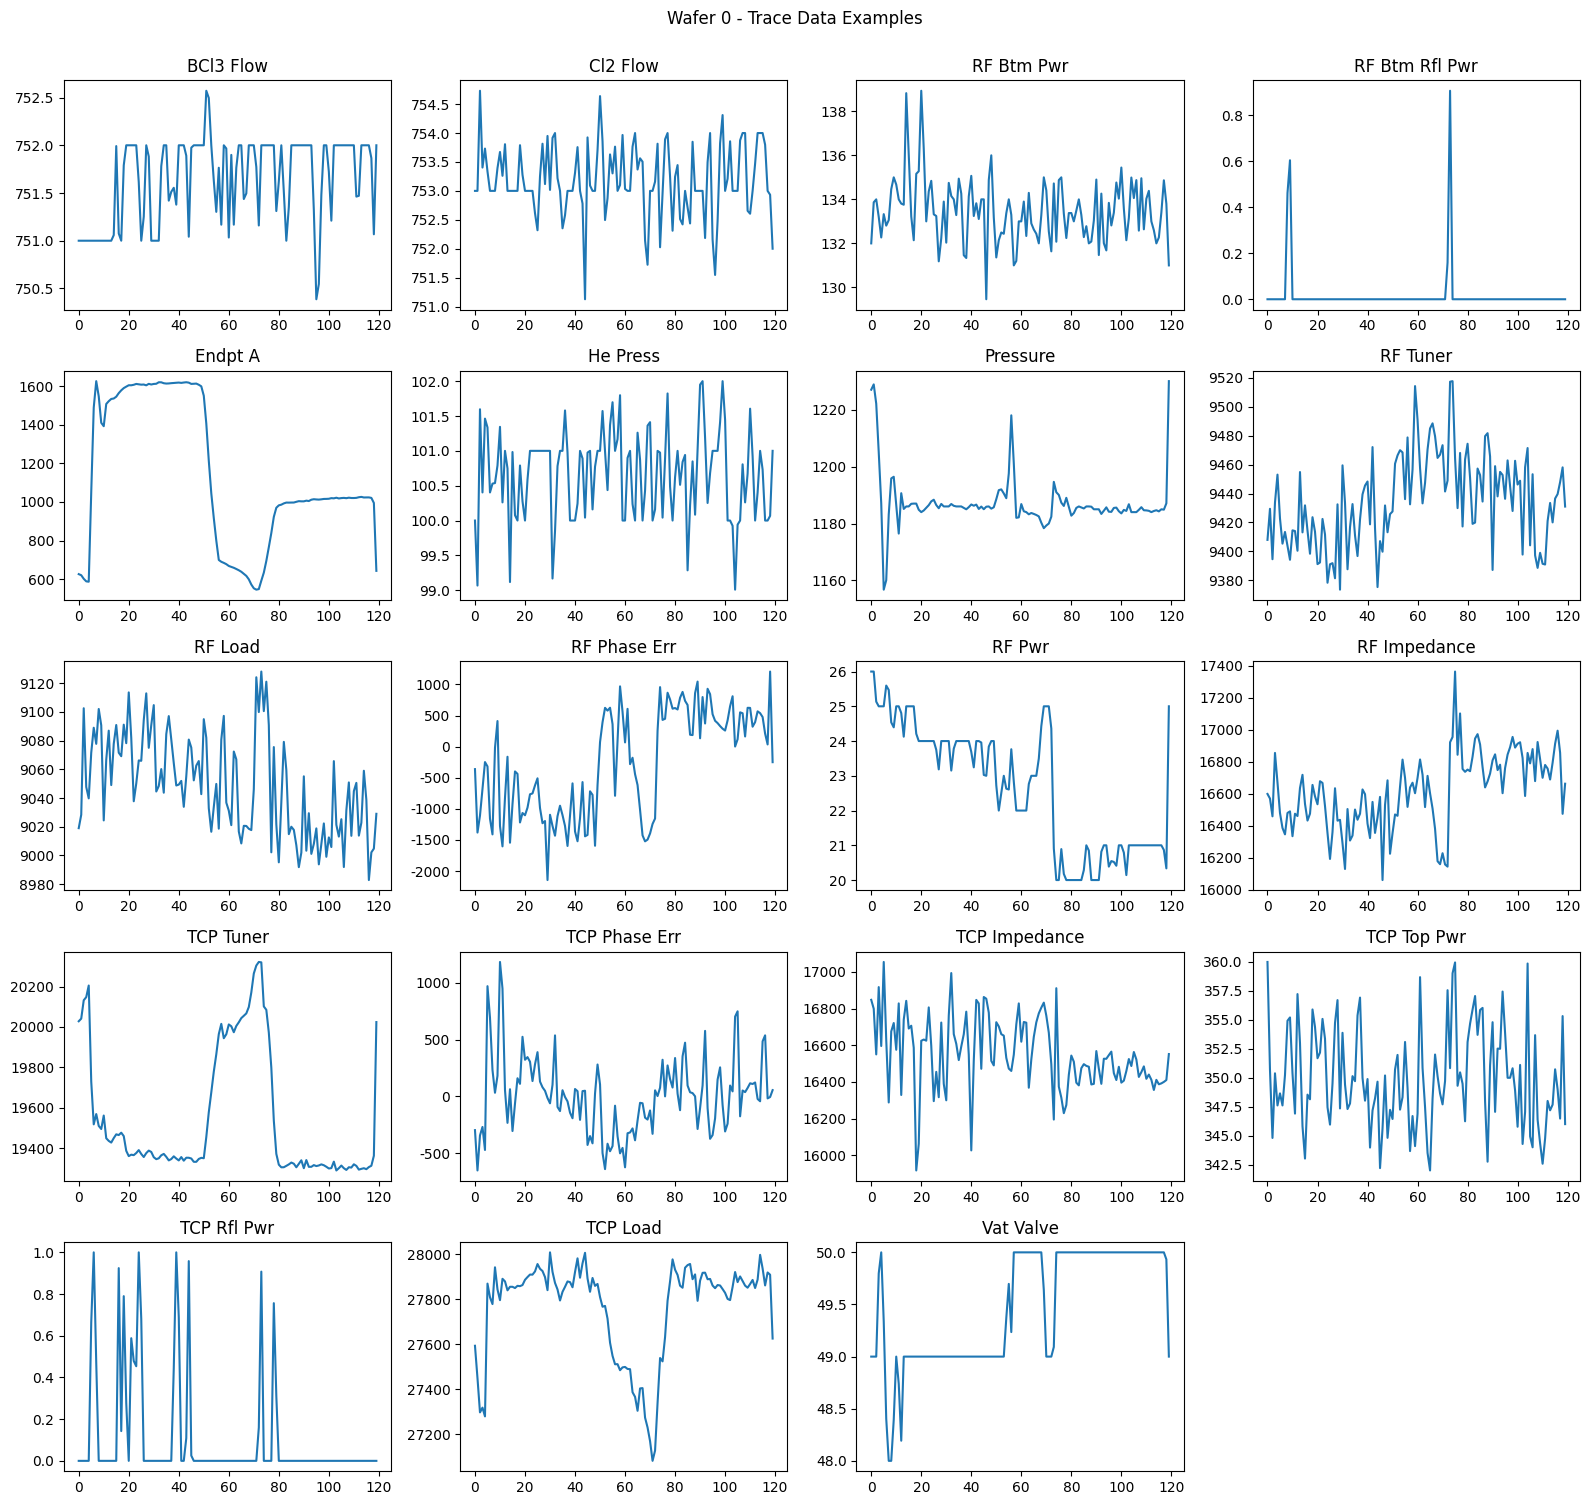

In [7]:
# 0번 웨이퍼의 모든 변수를 시계열로 시각화 (Step Number 제외)
sample = data.loc[0]
cols_to_plot = sample.columns.drop('Step Number')

n_cols = 4  # 한 줄에 그릴 그래프 개수
n_rows = -(-len(cols_to_plot) // n_cols)  # 올림 나눗셈으로 필요한 줄 수 계산

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()  

for i, col in enumerate(cols_to_plot):
    axes[i].plot(sample[col].values)
    axes[i].set_title(col)

for j in range(len(cols_to_plot), len(axes)):
    axes[j].axis('off')  # 남는 빈 칸은 숨김

plt.suptitle('Wafer 0 - Trace Data Examples', y=1.0)
plt.tight_layout()
plt.show()

---

## 2) 데이터 전처리

### 2-1) 불필요 변수 제거 및 스케일링

In [8]:
# Step Number는 공정 단계를 나타내는 변수이므로 분석에서 제외

data.drop("Step Number", axis=1, inplace=True)
print("변수 수:", data.shape[1])

변수 수: 19


In [9]:
# 센서마다 단위/범위가 다름
# 모든 변수를 [0,1]로 맞춰 비교와 요약 통계량 해석을 쉽게 하기 위해 MinMax 사용

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)
data = pd.DataFrame(scaled, index=data.index, columns=data.columns)
data

,BCl3 Flow,Cl2 Flow,RF Btm Pwr,RF Btm Rfl Pwr,Endpt A,He Press,Pressure,RF Tuner,RF Load,RF Phase Err,RF Pwr,RF Impedance,TCP Tuner,TCP Phase Err,TCP Impedance,TCP Top Pwr,TCP Rfl Pwr,TCP Load,Vat Valve
0,0.511361,0.558719,0.395652,0.000000,0.110639,0.369748,0.608123,0.196640,0.407337,0.584226,0.511071,0.491262,0.673741,0.303314,0.625601,0.948498,0.117241,0.428097,0.418719
0,0.511361,0.558719,0.511072,0.000000,0.108881,0.173981,0.612111,0.244356,0.426067,0.389463,0.511071,0.475377,0.680488,0.224203,0.609187,0.608216,0.117241,0.347737,0.418719
0,0.511361,0.803084,0.519391,0.000000,0.103045,0.704845,0.597597,0.166941,0.575148,0.441400,0.449431,0.414323,0.727484,0.292876,0.524820,0.394237,0.117241,0.262535,0.418719
0,0.511361,0.615658,0.469999,0.000000,0.098897,0.454404,0.561168,0.253813,0.465046,0.523174,0.439856,0.632181,0.735533,0.309597,0.649136,0.597793,0.117241,0.274316,0.485574
0,0.511361,0.661922,0.412289,0.000000,0.098303,0.676626,0.522854,0.296819,0.449049,0.605907,0.439856,0.530532,0.765205,0.264398,0.540313,0.496628,0.117241,0.252597,0.502463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,0.515734,0.590747,0.375895,0.000000,0.100687,0.694263,0.608123,0.106291,0.140509,0.890995,0.511071,0.317789,0.065995,0.296368,0.495968,0.327956,0.117241,0.878083,0.586207
128,0.522537,0.476868,0.441404,0.000000,0.100172,0.667808,0.608123,0.078312,0.177058,0.907634,0.552364,0.294897,0.085142,0.396483,0.504925,0.607539,0.117241,0.853797,0.586207
128,0.530635,0.526690,0.543306,0.386555,0.099644,0.579625,0.606470,0.161595,0.122218,0.811244,0.554758,0.383547,0.107355,0.485057,0.524888,0.751623,0.117241,0.847535,0.586207
128,0.530635,0.672598,0.581260,0.806723,0.099827,0.539060,0.604674,0.239814,0.047686,0.710199,0.511071,0.478747,0.123333,0.492870,0.536195,0.646779,0.139901,0.836582,0.586207


---

## 3) Trace Data → 머신러닝 입력 데이터로 변환

### 요약 통계량(Summary Statistics) 후보

> 시계열 데이터를 1행으로 요약할 때 사용할 수 있는 **통계량 후보**
>
> | 통계량 | 설명 | 적합한 데이터 특성 |
> |:---:|:---|:---|
> | **Mean** (평균) | 구간의 전반적인 수준 | 안정적인 센서, 전체 경향 파악 |
> | **Std** (표준편차) | 값의 흩어진 정도 | 진동, 불안정한 센서 |
> | **Variance** (분산) | 변동성의 크기 | Std와 유사, 제곱 스케일 |
> | **Min** (최솟값) | 구간 내 최저점 | 하한 이탈 감지 |
> | **Max** (최댓값) | 구간 내 최고점 | 상한 이탈 감지 |
> | **Range** (범위) | Max - Min | 값의 변동 폭 |
> | **Q25** (1사분위) | 하위 25% 지점 | 분포의 하단 특성 |
> | **Q50** (중앙값) | 하위 50% 지점 | 이상치에 강건한 중심값 |
> | **Q75** (3사분위) | 하위 75% 지점 | 분포의 상단 특성 |

### 3-1) 전체 구간 요약 (Simple Summary)

> 각 제품의 **전체 시계열**을 변수별로 요약하여 1행으로 만드는 방법
> - 장점: 구현이 간단
> - 단점: 시간에 따른 변화 패턴 정보가 사라짐

In [10]:
# 예시: 0번 웨이퍼의 변수별 평균
data.loc[0].mean()

BCl3 Flow         0.523757
Cl2 Flow          0.585083
RF Btm Pwr        0.486355
RF Btm Rfl Pwr    0.017787
Endpt A           0.272718
He Press          0.510136
Pressure          0.523068
RF Tuner          0.256533
RF Load           0.467918
RF Phase Err      0.603699
RF Pwr            0.271868
RF Impedance      0.501563
TCP Tuner         0.422124
TCP Phase Err     0.371361
TCP Impedance     0.526252
TCP Top Pwr       0.583803
TCP Rfl Pwr       0.129778
TCP Load          0.524479
Vat Valve         0.458380
dtype: float64

In [11]:
# 전체 웨이퍼에 대해 Mean, Std로 요약
data_summary = []
for wafer_idx in data.index.unique():  # 웨이퍼별로 반복
    temp = data.loc[wafer_idx]  # 해당 웨이퍼의 시점 정보 추출
    temp_summary = []
    for col in temp.columns:  # 변수별로 반복
        temp_summary.append(temp[col].mean())  # 해당 변수의 평균
        temp_summary.append(temp[col].std())   # 해당 변수의 표준편차
    data_summary.append(temp_summary)  # 웨이퍼 하나의 요약 통계를 리스트에 추가

data_summary = np.array(data_summary)  # 전체를 numpy 배열로 변환 (웨이퍼 수 x (변수 수*2))

print("요약 데이터 크기:", data_summary.shape)
print(f"→ {len(data.index.unique())}개 웨이퍼 × ({len(data.columns)}개 변수 × 2개 통계량)")

요약 데이터 크기: (129, 38)
→ 129개 웨이퍼 × (19개 변수 × 2개 통계량)


In [12]:
# 컬럼명 생성 (각 원본 변수마다 Mean, Std 두 개씩)
cols = []
for col in data.columns:
    cols.extend([col + '_Mean', col + '_Std'])  # 예: 'RF Btm Pwr_Mean', 'RF Btm Pwr_Std'

# numpy 배열을 DataFrame으로 변환 + 컬럼명 지정
simple_summary = pd.DataFrame(data_summary, columns=cols)
simple_summary

,BCl3 Flow_Mean,BCl3 Flow_Std,Cl2 Flow_Mean,Cl2 Flow_Std,RF Btm Pwr_Mean,RF Btm Pwr_Std,RF Btm Rfl Pwr_Mean,RF Btm Rfl Pwr_Std,Endpt A_Mean,Endpt A_Std,...,TCP Impedance_Mean,TCP Impedance_Std,TCP Top Pwr_Mean,TCP Top Pwr_Std,TCP Rfl Pwr_Mean,TCP Rfl Pwr_Std,TCP Load_Mean,TCP Load_Std,Vat Valve_Mean,Vat Valve_Std
0,0.523757,0.008694,0.585083,0.086170,0.486355,0.087460,0.017787,0.108112,0.272718,0.119195,...,0.526252,0.066211,0.583803,0.156939,0.129778,0.030836,0.524479,0.121741,0.458380,0.046214
1,0.525246,0.007329,0.578094,0.077257,0.474518,0.073812,0.010014,0.090705,0.278572,0.125736,...,0.522100,0.066667,0.556310,0.143814,0.130369,0.031106,0.530764,0.130548,0.457037,0.045342
2,0.522982,0.007903,0.589235,0.085635,0.470380,0.077469,0.000000,0.000000,0.285295,0.129797,...,0.526595,0.065073,0.543097,0.141925,0.133736,0.035531,0.534498,0.138545,0.457430,0.044085
3,0.524711,0.007350,0.581554,0.081651,0.458877,0.078458,0.000000,0.000000,0.286315,0.132098,...,0.516816,0.067512,0.587066,0.127076,0.134368,0.035763,0.525254,0.125728,0.458075,0.043920
4,0.524918,0.008056,0.578598,0.081402,0.468353,0.060809,0.000000,0.000000,0.289958,0.133271,...,0.520427,0.061924,0.558137,0.165919,0.131732,0.031512,0.533673,0.129399,0.460063,0.044095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,0.526524,0.006913,0.581367,0.074842,0.485240,0.084821,0.000000,0.000000,0.114010,0.066861,...,0.494755,0.064159,0.573907,0.135505,0.138013,0.037801,0.717750,0.155592,0.383861,0.040661
125,0.524627,0.008594,0.607918,0.082623,0.476118,0.074254,0.000000,0.000000,0.109602,0.066323,...,0.510733,0.076942,0.585410,0.156046,0.138900,0.039384,0.712200,0.146260,0.457260,0.043819
126,0.525995,0.008824,0.579498,0.080450,0.478591,0.090028,0.020448,0.131562,0.101489,0.057687,...,0.522362,0.061403,0.572267,0.141153,0.137701,0.037578,0.775177,0.133637,0.653859,0.088332
127,0.524423,0.008035,0.589779,0.075219,0.480371,0.070346,0.032073,0.144075,0.102761,0.066044,...,0.509995,0.063144,0.546312,0.150696,0.131782,0.031609,0.798606,0.154819,0.370109,0.043247


---

### 3-2) 구간별 요약 (Step-based Summary)

> 시계열을 **누적 구간으로 나누어** 각 구간별로 요약하는 방법
>
> 예시: 120개 시점을 6개 누적 구간으로 나누기
> ```
> step_list = [20, 40, 60, 80, 100, -1]
> ```
> | 구간 | 시점 범위 | 설명 |
> |:---:|:---:|:---|
> | Step 0 | 0 ~ 19 | 처음 20개 시점 (공정 초기) |
> | Step 1 | 0 ~ 39 | 처음 40개 시점까지 누적 |
> | Step 2 | 0 ~ 59 | 처음 60개 시점까지 누적 |
> | Step 3 | 0 ~ 79 | 처음 80개 시점까지 누적 |
> | Step 4 | 0 ~ 99 | 처음 100개 시점까지 누적 |
> | Step 5 | 0 ~ 끝 | 전체 시점 (전 구간 누적) |
>
> 매 구간마다 이전 구간을 포함해서 범위가 점점 넓어지는 방식 
> - 공정이 진행될수록 누적된 패턴이 어떻게 변화하는지 포착할 수 있음

In [13]:
step_list = [20, 40, 60, 80, 100, -1]

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_7591/4051806674.py:15: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
 

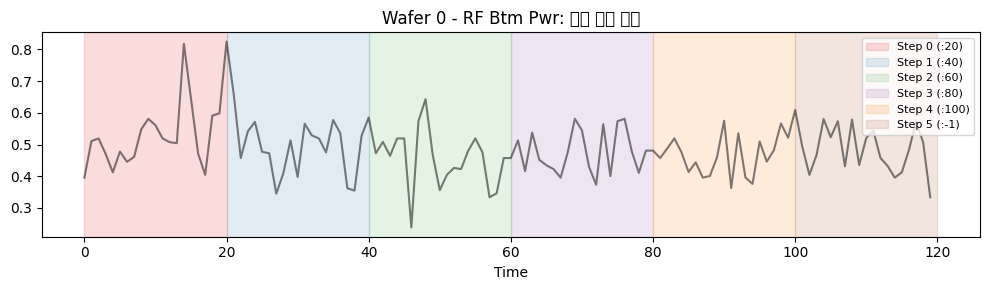

In [14]:
# 구간별 요약 시각화: 0번 웨이퍼의 'RF Btm Pwr' 변수
sample = data.loc[0]['RF Btm Pwr']

plt.figure(figsize=(10, 3))
plt.plot(range(len(sample)), sample.values, color='black', alpha=0.5)
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']
prev = 0
for i, step in enumerate(step_list):
    end = step if step != -1 else len(sample)
    plt.axvspan(prev, end, alpha=0.15, color=colors[i], label=f'Step {i} (:{step})')
    prev = end
plt.title('Wafer 0 - RF Btm Pwr: 구간 분할 예시')
plt.xlabel('Time')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

In [15]:
# 구간별(누적) Mean, Std 요약
data_summary = []

for wafer_idx in data.index.unique():  # 웨이퍼별로 반복
    temp = data.loc[wafer_idx]  # 해당 웨이퍼의 시점 정보 추출
    temp_summary = []
    for col in temp.columns:  # 변수별로 반복
        for step in step_list:  # 누적 구간별로 반복 (0~step 시점까지)
            segment = temp[col][:step]  # 해당 구간(0부터 step까지)의 데이터 추출
            temp_summary.append(segment.mean())  # 해당 구간의 평균
            temp_summary.append(segment.std())   # 해당 구간의 표준편차
    data_summary.append(temp_summary)  # 웨이퍼 하나의 요약 통계를 리스트에 추가

data_summary = np.array(data_summary)  # 전체를 numpy 배열로 변환 (웨이퍼 수 x (변수 수 * 구간 수 * 2))

print("요약 데이터 크기:", data_summary.shape)
print(f"→ {len(data.index.unique())}개 웨이퍼 × ({len(data.columns)}개 변수 × {len(step_list)}개 구간 × 2개 통계량)")

요약 데이터 크기: (129, 228)
→ 129개 웨이퍼 × (19개 변수 × 6개 구간 × 2개 통계량)


In [16]:
# 컬럼명 생성
cols = []
for col in data.columns:
    for step_num in range(len(step_list)):
        cols.extend([f'{col}_Step{step_num}_Mean', f'{col}_Step{step_num}_Std'])

step_summary = pd.DataFrame(data_summary, columns=cols)
step_summary

,BCl3 Flow_Step0_Mean,BCl3 Flow_Step0_Std,BCl3 Flow_Step1_Mean,BCl3 Flow_Step1_Std,BCl3 Flow_Step2_Mean,BCl3 Flow_Step2_Std,BCl3 Flow_Step3_Mean,BCl3 Flow_Step3_Std,BCl3 Flow_Step4_Mean,BCl3 Flow_Step4_Std,...,Vat Valve_Step1_Mean,Vat Valve_Step1_Std,Vat Valve_Step2_Mean,Vat Valve_Step2_Std,Vat Valve_Step3_Mean,Vat Valve_Step3_Std,Vat Valve_Step4_Mean,Vat Valve_Step4_Std,Vat Valve_Step5_Mean,Vat Valve_Step5_Std
0,0.514171,0.006546,0.518257,0.008290,0.521678,0.009264,0.522723,0.008836,0.522999,0.009010,...,0.414251,0.030215,0.421745,0.032326,0.437456,0.042431,0.450457,0.046040,0.458714,0.046265
1,0.522067,0.008294,0.523654,0.007533,0.524707,0.007389,0.525234,0.007503,0.524809,0.007404,...,0.413881,0.025357,0.419505,0.027042,0.435486,0.039984,0.448881,0.044730,0.457359,0.045396
2,0.516406,0.006926,0.519751,0.008012,0.520790,0.007964,0.522061,0.008073,0.522744,0.008073,...,0.418596,0.025935,0.421839,0.026129,0.436084,0.038157,0.449360,0.043289,0.457756,0.044126
3,0.519630,0.007844,0.522347,0.007636,0.523258,0.007469,0.523997,0.007343,0.525106,0.007122,...,0.418438,0.026445,0.423376,0.027838,0.437069,0.038439,0.450148,0.043246,0.458406,0.043955
4,0.517492,0.007893,0.521257,0.009289,0.523646,0.008709,0.523193,0.008381,0.524665,0.008052,...,0.418455,0.026349,0.425698,0.031000,0.440042,0.040296,0.452526,0.043880,0.460411,0.044116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,0.520990,0.008140,0.524744,0.007581,0.526354,0.006979,0.526343,0.006902,0.526340,0.007060,...,0.348997,0.030392,0.353612,0.033984,0.366432,0.039593,0.376890,0.041143,0.383568,0.040706
125,0.516010,0.007314,0.519901,0.009486,0.522353,0.009399,0.523869,0.008883,0.524751,0.008446,...,0.418526,0.026465,0.423516,0.028084,0.435864,0.037599,0.449184,0.042952,0.457584,0.043860
126,0.516797,0.009776,0.521907,0.010027,0.523983,0.009812,0.525025,0.009428,0.525394,0.009058,...,0.576689,0.059000,0.586582,0.058876,0.608761,0.064567,0.637748,0.081985,0.655835,0.086001
127,0.515062,0.008607,0.520018,0.009273,0.521862,0.009014,0.523163,0.008580,0.524385,0.008210,...,0.339937,0.034586,0.341954,0.031949,0.345804,0.031980,0.360387,0.040931,0.369701,0.043197


---

### 3-3) 다양한 통계량을 활용한 구간별 요약

> **다양한 통계량을 조합**하면 더 풍부한 정보를 머신러닝 모델에 제공할 수 있음

In [17]:
# 사용할 통계량 정의
stat_funcs = {
    'Mean': lambda x: x.mean(),
    'Std': lambda x: x.std(),
    'Min': lambda x: x.min(),
    'Max': lambda x: x.max(),
    'Range': lambda x: x.max() - x.min(),
    'Q25': lambda x: x.quantile(0.25),
    'Q50': lambda x: x.quantile(0.50),
    'Q75': lambda x: x.quantile(0.75),
}

print("사용할 통계량:", list(stat_funcs.keys()))

사용할 통계량: ['Mean', 'Std', 'Min', 'Max', 'Range', 'Q25', 'Q50', 'Q75']


In [18]:
step_list = [20, 40, 60, 80, 100, -1]

data_summary = []
for wafer_idx in data.index.unique():
    temp = data.loc[wafer_idx]
    temp_summary = []
    for col in temp.columns:
        for step in step_list:
            segment = temp[col][:step]
            for func in stat_funcs.values():
                temp_summary.append(func(segment))
    data_summary.append(temp_summary)

data_summary = np.array(data_summary)
print("요약 데이터 크기:", data_summary.shape)
print(f"→ {len(data.index.unique())}개 웨이퍼 × ({len(data.columns)}개 변수 × {len(step_list)}개 구간 × {len(stat_funcs)}개 통계량)")

요약 데이터 크기: (129, 912)
→ 129개 웨이퍼 × (19개 변수 × 6개 구간 × 8개 통계량)


In [19]:
# 컬럼명 생성
cols = []
for col in data.columns:
    for step_num in range(len(step_list)):
        for stat_name in stat_funcs.keys():
            cols.append(f'{col}_Step{step_num}_{stat_name}')

full_summary = pd.DataFrame(data_summary, columns=cols)

print("최종 변수 수:", full_summary.shape[1])
full_summary

최종 변수 수: 912


,BCl3 Flow_Step0_Mean,BCl3 Flow_Step0_Std,BCl3 Flow_Step0_Min,BCl3 Flow_Step0_Max,BCl3 Flow_Step0_Range,BCl3 Flow_Step0_Q25,BCl3 Flow_Step0_Q50,BCl3 Flow_Step0_Q75,BCl3 Flow_Step1_Mean,BCl3 Flow_Step1_Std,...,Vat Valve_Step4_Q50,Vat Valve_Step4_Q75,Vat Valve_Step5_Mean,Vat Valve_Step5_Std,Vat Valve_Step5_Min,Vat Valve_Step5_Max,Vat Valve_Step5_Range,Vat Valve_Step5_Q25,Vat Valve_Step5_Q50,Vat Valve_Step5_Q75
0,0.514171,0.006546,0.511361,0.530635,0.019274,0.511361,0.511361,0.511644,0.518257,0.008290,...,0.418719,0.502463,0.458714,0.046265,0.334975,0.502463,0.167488,0.418719,0.477129,0.502463
1,0.522067,0.008294,0.511361,0.530635,0.019274,0.513386,0.522375,0.530635,0.523654,0.007533,...,0.418719,0.502463,0.457359,0.045396,0.334975,0.502463,0.167488,0.418719,0.464462,0.502463
2,0.516406,0.006926,0.511361,0.530635,0.019274,0.511361,0.511361,0.522982,0.519751,0.008012,...,0.418719,0.502463,0.457756,0.044126,0.334975,0.502463,0.167488,0.418719,0.443350,0.502463
3,0.519630,0.007844,0.511361,0.530635,0.019274,0.511361,0.518245,0.527477,0.522347,0.007636,...,0.418719,0.502463,0.458406,0.043955,0.334975,0.502463,0.167488,0.418719,0.453202,0.502463
4,0.517492,0.007893,0.511361,0.530635,0.019274,0.511361,0.511361,0.523104,0.521257,0.009289,...,0.418719,0.502463,0.460411,0.044116,0.334975,0.502463,0.167488,0.418719,0.486981,0.502463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,0.520990,0.008140,0.511361,0.530635,0.019274,0.511361,0.521808,0.529056,0.524744,0.007581,...,0.374384,0.418719,0.383568,0.040706,0.334975,0.418719,0.083744,0.334975,0.418719,0.418719
125,0.516010,0.007314,0.511361,0.530635,0.019274,0.511361,0.511361,0.518285,0.519901,0.009486,...,0.418719,0.502463,0.457584,0.043860,0.334975,0.502463,0.167488,0.418719,0.450387,0.502463
126,0.516797,0.009776,0.495150,0.533699,0.038549,0.514424,0.514424,0.522968,0.521907,0.010027,...,0.588670,0.687368,0.655835,0.086001,0.418719,0.753695,0.334975,0.586207,0.669951,0.753695
127,0.515062,0.008607,0.495164,0.530635,0.035471,0.511361,0.512333,0.518488,0.520018,0.009273,...,0.334975,0.418719,0.369701,0.043197,0.251232,0.418719,0.167488,0.334975,0.334975,0.418719


> **참고**
> - 통계량을 많이 사용하면 변수 수가 급격히 늘어남
> - 변수가 너무 많으면 **차원의 저주**가 발생할 수 있으므로, 이후 mRMR, Boruta 등의 **차원 축소** 기법을 적용하는 것이 좋음

---

## 4) Vibe Coding 실습

**[과제 1]** 

지수는 지금까지 모든 변수에 Mean, Std 같은 통계량을 똑같이 적용해서 요약했는데
변수마다 분포 특성이 다르다는 걸 알게 되었습니다.

AI와 상의하여 변수별 분포 특성을 분석하는 코드를 작성하고 변수마다 적합한 통계량을 추천받아 요약해 보세요.

In [20]:
from scipy import stats

# 센서 변수만 선택
sensor_cols = [c for c in data.columns if c != "Step Number"]

def analyze_trace_distribution(data, sensor_cols, cv_threshold=0.05, skew_threshold=1.0):
    """
    모든 웨이퍼·시점을 pooling하여 변수별 분포 특성 진단
    """
    profiles = []

    for col in sensor_cols:
        s = data[col]
        mean_val = s.mean()
        std_val = s.std()
        cv = std_val / (abs(mean_val) + 1e-9)
        skew = stats.skew(s)
        kurt = stats.kurtosis(s)
        zero_ratio = (s == 0).mean()

        # 웨이퍼 단위 변동성
        wafer_std = data.groupby(level=0)[col].std().mean()
        wafer_range = (
            data.groupby(level=0)[col].max() - data.groupby(level=0)[col].min()
        ).mean()

        # 시간축 추세 (웨이퍼별 선형 상관 평균)
        def time_corr(series):
            if len(series) < 3 or series.std() == 0:
                return 0
            t = np.arange(len(series))
            return abs(np.corrcoef(t, series.values)[0, 1])

        trend_strength = data.groupby(level=0)[col].apply(time_corr).mean()

        # 분포 유형 라벨링
        if zero_ratio >= 0.5:
            dist_type = "희소/스파이크형"       # 대부분 0, 가끔 spike
        elif cv >= cv_threshold or wafer_std > std_val * 0.3:
            dist_type = "고변동형"              # 진동·불안정
        elif abs(skew) >= skew_threshold:
            dist_type = "왜도형"                  # 비대칭 분포
        elif trend_strength >= 0.4:
            dist_type = "추세형"                  # 시간에 따라 증감
        else:
            dist_type = "안정형"                  # 비교적 일정

        profiles.append({
            "variable": col,
            "mean": mean_val,
            "std": std_val,
            "cv": cv,
            "skew": skew,
            "kurtosis": kurt,
            "zero_ratio": zero_ratio,
            "wafer_std": wafer_std,
            "wafer_range": wafer_range,
            "trend_strength": trend_strength,
            "dist_type": dist_type,
        })

    profile_df = pd.DataFrame(profiles).sort_values("cv", ascending=False)
    return profile_df

# 실행
profile_df = analyze_trace_distribution(data, sensor_cols)
display(profile_df)

,variable,mean,std,cv,skew,kurtosis,zero_ratio,wafer_std,wafer_range,trend_strength,dist_type
3,RF Btm Rfl Pwr,0.012615,0.092491,7.331598,8.217348,70.402171,0.975258,0.068852,0.539248,0.072812,희소/스파이크형
4,Endpt A,0.310250,0.234194,0.754856,0.919668,-0.047524,0.000065,0.142961,0.406986,0.501076,고변동형
12,TCP Tuner,0.372072,0.189445,0.509163,0.909752,-0.396378,0.000065,0.182244,0.671183,0.204536,고변동형
10,RF Pwr,0.514646,0.186959,0.363277,-0.390679,-0.520159,0.000065,0.104400,0.414555,0.631342,고변동형
9,RF Phase Err,0.551850,0.173211,0.313874,-0.069301,-0.903181,0.000065,0.166407,0.690051,0.544402,고변동형
7,RF Tuner,0.298883,0.091621,0.306545,0.813325,4.202917,0.000065,0.068566,0.337276,0.256331,고변동형
11,RF Impedance,0.486213,0.146709,0.301739,-0.180952,-0.307055,0.000065,0.138451,0.677174,0.307147,고변동형
17,TCP Load,0.601953,0.179189,0.297679,-0.375191,-0.104839,0.000065,0.141460,0.580424,0.130447,고변동형
16,TCP Rfl Pwr,0.138906,0.039188,0.282119,2.311304,17.232453,0.000065,0.038258,0.138557,0.209407,고변동형
8,RF Load,0.384007,0.100110,0.260698,0.508518,2.035028,0.000065,0.071577,0.342219,0.446778,고변동형


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_7591/2303477374.py:12: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_7591/2303477374.py:

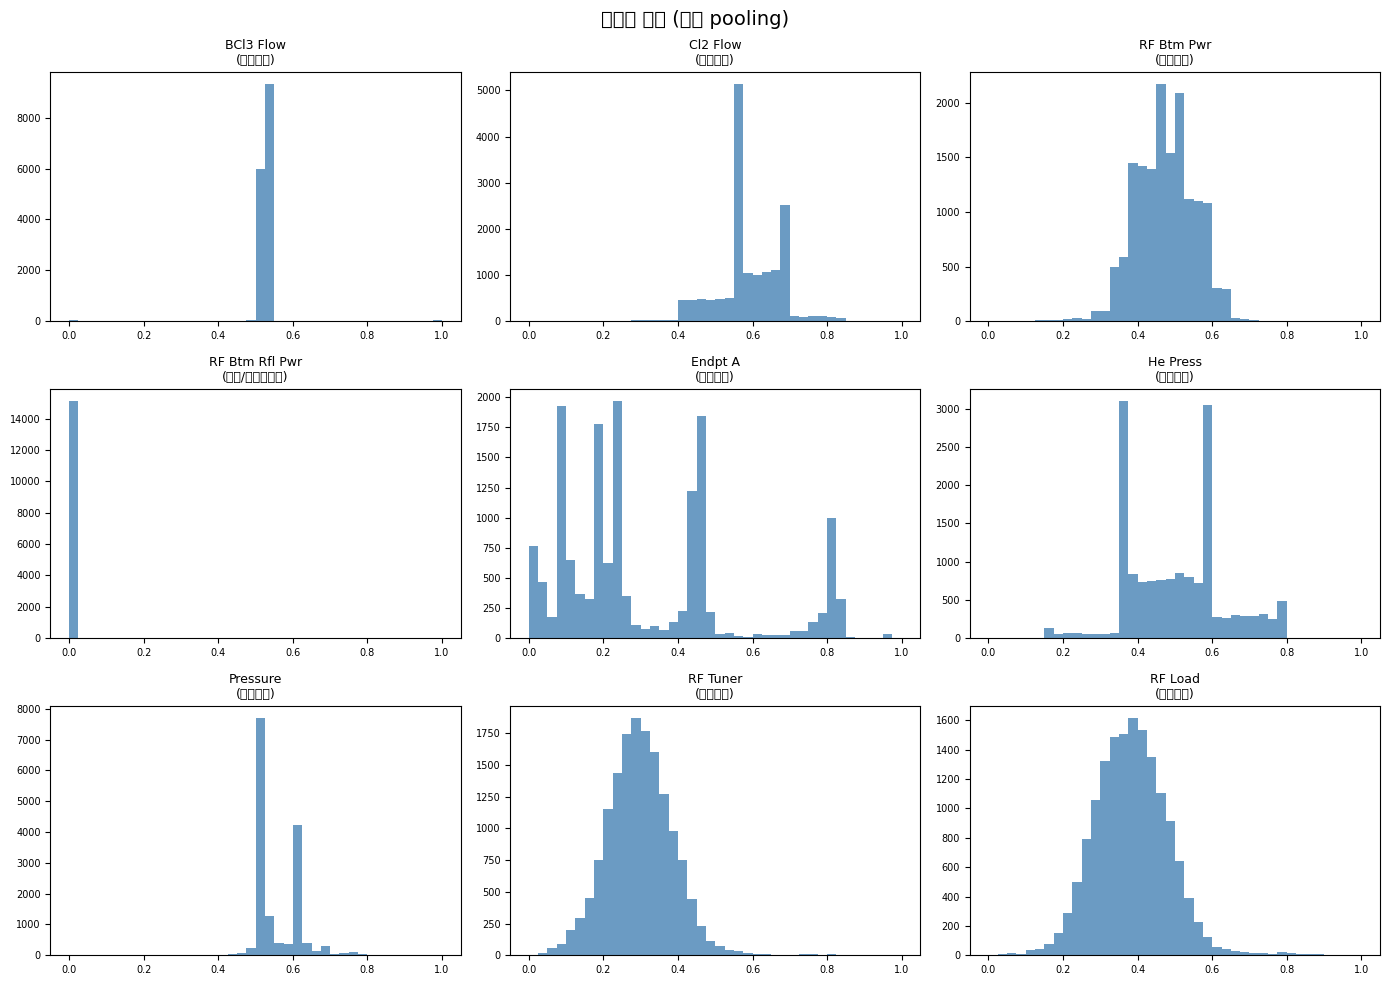

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_7591/2303477374.py:26: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_7591/2303477374.py:

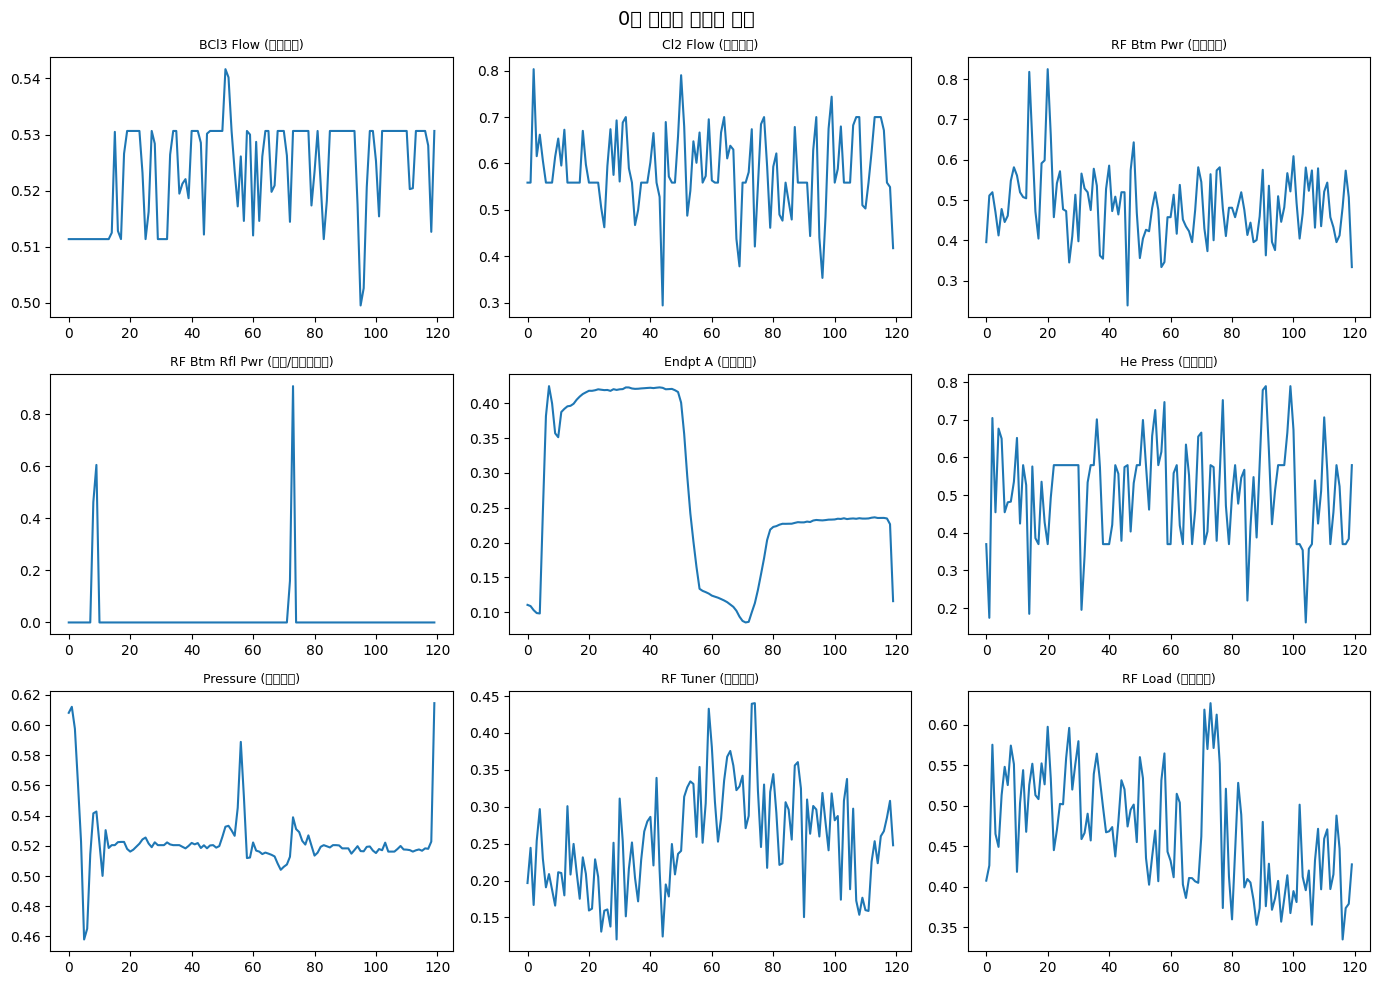

In [21]:
# 분포 유형별 대표 변수 히스토그램
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(sensor_cols[:9]):
    axes[i].hist(data[col], bins=40, color="steelblue", alpha=0.8)
    dtype = profile_df.loc[profile_df["variable"] == col, "dist_type"].values[0]
    axes[i].set_title(f"{col}\n({dtype})", fontsize=9)
    axes[i].tick_params(labelsize=7)

plt.suptitle("변수별 분포 (전체 pooling)", fontsize=14)
plt.tight_layout()
plt.show()

# 0번 웨이퍼 시계열 패턴 비교
sample_wafer = data.loc[data.index.unique()[0], sensor_cols]
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(sensor_cols[:9]):
    axes[i].plot(sample_wafer[col].values)
    dtype = profile_df.loc[profile_df["variable"] == col, "dist_type"].values[0]
    axes[i].set_title(f"{col} ({dtype})", fontsize=9)

plt.suptitle("0번 웨이퍼 시계열 패턴", fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
# 노트북과 동일한 통계량 정의
STAT_FUNCS = {
    "Mean":  lambda x: x.mean(),
    "Std":   lambda x: x.std(),
    "Min":   lambda x: x.min(),
    "Max":   lambda x: x.max(),
    "Range": lambda x: x.max() - x.min(),
    "Q25":   lambda x: x.quantile(0.25),
    "Q50":   lambda x: x.quantile(0.50),
    "Q75":   lambda x: x.quantile(0.75),
}

# 분포 유형 → 추천 통계량 (변수당 2~3개)
STAT_RECOMMENDATION = {
    "안정형":      ["Mean", "Std"],
    "고변동형":    ["Std", "Range", "Q50"],
    "왜도형":      ["Q50", "Q25", "Q75"],
    "희소/스파이크형": ["Max", "Range", "Std"],
    "추세형":      ["Mean", "Min", "Max"],
}

def recommend_stats(profile_df):
    """변수별 추천 통계량 테이블 생성"""
    rec_rows = []
    for _, row in profile_df.iterrows():
        stats_list = STAT_RECOMMENDATION[row["dist_type"]]
        rec_rows.append({
            "variable": row["variable"],
            "dist_type": row["dist_type"],
            "recommended_stats": ", ".join(stats_list),
            "n_stats": len(stats_list),
        })
    return pd.DataFrame(rec_rows)

recommend_df = recommend_stats(profile_df)
display(recommend_df)

# 유형별 요약
print(recommend_df.groupby("dist_type")["variable"].apply(list))

,variable,dist_type,recommended_stats,n_stats
0,RF Btm Rfl Pwr,희소/스파이크형,"Max, Range, Std",3
1,Endpt A,고변동형,"Std, Range, Q50",3
2,TCP Tuner,고변동형,"Std, Range, Q50",3
3,RF Pwr,고변동형,"Std, Range, Q50",3
4,RF Phase Err,고변동형,"Std, Range, Q50",3
5,RF Tuner,고변동형,"Std, Range, Q50",3
6,RF Impedance,고변동형,"Std, Range, Q50",3
7,TCP Load,고변동형,"Std, Range, Q50",3
8,TCP Rfl Pwr,고변동형,"Std, Range, Q50",3
9,RF Load,고변동형,"Std, Range, Q50",3


dist_type
고변동형        [Endpt A, TCP Tuner, RF Pwr, RF Phase Err, RF ...
희소/스파이크형                                     [RF Btm Rfl Pwr]
Name: variable, dtype: object


In [23]:
def adaptive_simple_summary(data, sensor_cols, profile_df):
    """
    웨이퍼별로 변수마다 추천된 통계량만 계산
    """
    stat_map = {
        row["variable"]: STAT_RECOMMENDATION[row["dist_type"]]
        for _, row in profile_df.iterrows()
    }

    summary_rows = []
    col_names = []

    # 컬럼명 미리 생성
    for col in sensor_cols:
        for stat_name in stat_map[col]:
            col_names.append(f"{col}_{stat_name}")

    # 웨이퍼별 요약
    for wafer_id in data.index.unique():
        temp = data.loc[wafer_id, sensor_cols]
        row_values = []
        for col in sensor_cols:
            for stat_name in stat_map[col]:
                row_values.append(STAT_FUNCS[stat_name](temp[col]))
        summary_rows.append(row_values)

    adaptive_summary = pd.DataFrame(summary_rows, index=data.index.unique(), columns=col_names)
    return adaptive_summary, stat_map

adaptive_simple, stat_map = adaptive_simple_summary(data, sensor_cols, profile_df)

print("기존 Mean+Std 요약 변수 수:", len(sensor_cols) * 2)
print("맞춤 요약 변수 수:", adaptive_simple.shape[1])
display(adaptive_simple.head())

기존 Mean+Std 요약 변수 수: 38
맞춤 요약 변수 수: 57


,BCl3 Flow_Std,BCl3 Flow_Range,BCl3 Flow_Q50,Cl2 Flow_Std,Cl2 Flow_Range,Cl2 Flow_Q50,RF Btm Pwr_Std,RF Btm Pwr_Range,RF Btm Pwr_Q50,RF Btm Rfl Pwr_Max,...,TCP Top Pwr_Q50,TCP Rfl Pwr_Std,TCP Rfl Pwr_Range,TCP Rfl Pwr_Q50,TCP Load_Std,TCP Load_Range,TCP Load_Q50,Vat Valve_Std,Vat Valve_Range,Vat Valve_Q50
0,0.008694,0.042112,0.529340,0.086170,0.508897,0.558719,0.087460,0.585939,0.478578,0.907563,...,0.568670,0.030836,0.117241,0.117241,0.121741,0.518170,0.576599,0.046214,0.167488,0.474666
1,0.007329,0.026887,0.530635,0.077257,0.385528,0.558719,0.073812,0.459601,0.474158,0.983193,...,0.552882,0.031106,0.117241,0.117241,0.130548,0.497833,0.592376,0.045342,0.167488,0.446517
2,0.007903,0.027211,0.524966,0.085635,0.498221,0.558719,0.077469,0.465840,0.464800,0.000000,...,0.533262,0.035531,0.117241,0.117241,0.138545,0.538760,0.593095,0.044085,0.167488,0.433498
3,0.007350,0.019274,0.530068,0.081651,0.474496,0.558719,0.078458,0.348340,0.457521,0.000000,...,0.571582,0.035763,0.117241,0.117241,0.125728,0.567333,0.578085,0.043920,0.167488,0.452498
4,0.008056,0.033690,0.530149,0.081402,0.486358,0.558719,0.060809,0.263075,0.457521,0.000000,...,0.536941,0.031512,0.117241,0.117241,0.129399,0.533768,0.592846,0.044095,0.167488,0.479240


In [24]:
step_list = [20, 40, 60, 80, 100, -1]

def adaptive_step_summary(data, sensor_cols, profile_df, step_list):
    stat_map = {
        row["variable"]: STAT_RECOMMENDATION[row["dist_type"]]
        for _, row in profile_df.iterrows()
    }

    col_names = []
    for col in sensor_cols:
        for step_num in range(len(step_list)):
            for stat_name in stat_map[col]:
                col_names.append(f"{col}_Step{step_num}_{stat_name}")

    summary_rows = []
    for wafer_id in data.index.unique():
        temp = data.loc[wafer_id, sensor_cols]
        row_values = []

        for col in sensor_cols:
            for step in step_list:
                segment = temp.loc[:step, col] if step != -1 else temp[col]
                for stat_name in stat_map[col]:
                    row_values.append(STAT_FUNCS[stat_name](segment))

        summary_rows.append(row_values)

    return pd.DataFrame(summary_rows, index=data.index.unique(), columns=col_names)

adaptive_step = adaptive_step_summary(data, sensor_cols, profile_df, step_list)
print("기존 step 요약 변수 수:", len(sensor_cols) * len(step_list) * 2)
print("맞춤 step 요약 변수 수:", adaptive_step.shape[1])
display(adaptive_step.head())

기존 step 요약 변수 수: 228
맞춤 step 요약 변수 수: 342


,BCl3 Flow_Step0_Std,BCl3 Flow_Step0_Range,BCl3 Flow_Step0_Q50,BCl3 Flow_Step1_Std,BCl3 Flow_Step1_Range,BCl3 Flow_Step1_Q50,BCl3 Flow_Step2_Std,BCl3 Flow_Step2_Range,BCl3 Flow_Step2_Q50,BCl3 Flow_Step3_Std,...,Vat Valve_Step2_Q50,Vat Valve_Step3_Std,Vat Valve_Step3_Range,Vat Valve_Step3_Q50,Vat Valve_Step4_Std,Vat Valve_Step4_Range,Vat Valve_Step4_Q50,Vat Valve_Step5_Std,Vat Valve_Step5_Range,Vat Valve_Step5_Q50
0,0.008694,0.042112,0.529340,0.008694,0.042112,0.529340,0.008694,0.042112,0.529340,0.008694,...,0.474666,0.046214,0.167488,0.474666,0.046214,0.167488,0.474666,0.046214,0.167488,0.474666
1,0.007329,0.026887,0.530635,0.007329,0.026887,0.530635,0.007329,0.026887,0.530635,0.007329,...,0.446517,0.045342,0.167488,0.446517,0.045342,0.167488,0.446517,0.045342,0.167488,0.446517
2,0.007903,0.027211,0.524966,0.007903,0.027211,0.524966,0.007903,0.027211,0.524966,0.007903,...,0.433498,0.044085,0.167488,0.433498,0.044085,0.167488,0.433498,0.044085,0.167488,0.433498
3,0.007350,0.019274,0.530068,0.007350,0.019274,0.530068,0.007350,0.019274,0.530068,0.007350,...,0.452498,0.043920,0.167488,0.452498,0.043920,0.167488,0.452498,0.043920,0.167488,0.452498
4,0.008056,0.033690,0.530149,0.008056,0.033690,0.530149,0.008056,0.033690,0.530149,0.008056,...,0.479240,0.044095,0.167488,0.479240,0.044095,0.167488,0.479240,0.044095,0.167488,0.479240


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_7591/2371379227.py:23: UserWarning: Glyph 55148 (\N{HANGUL SYLLABLE HYI}) missing from font(s) DejaVu Sans.


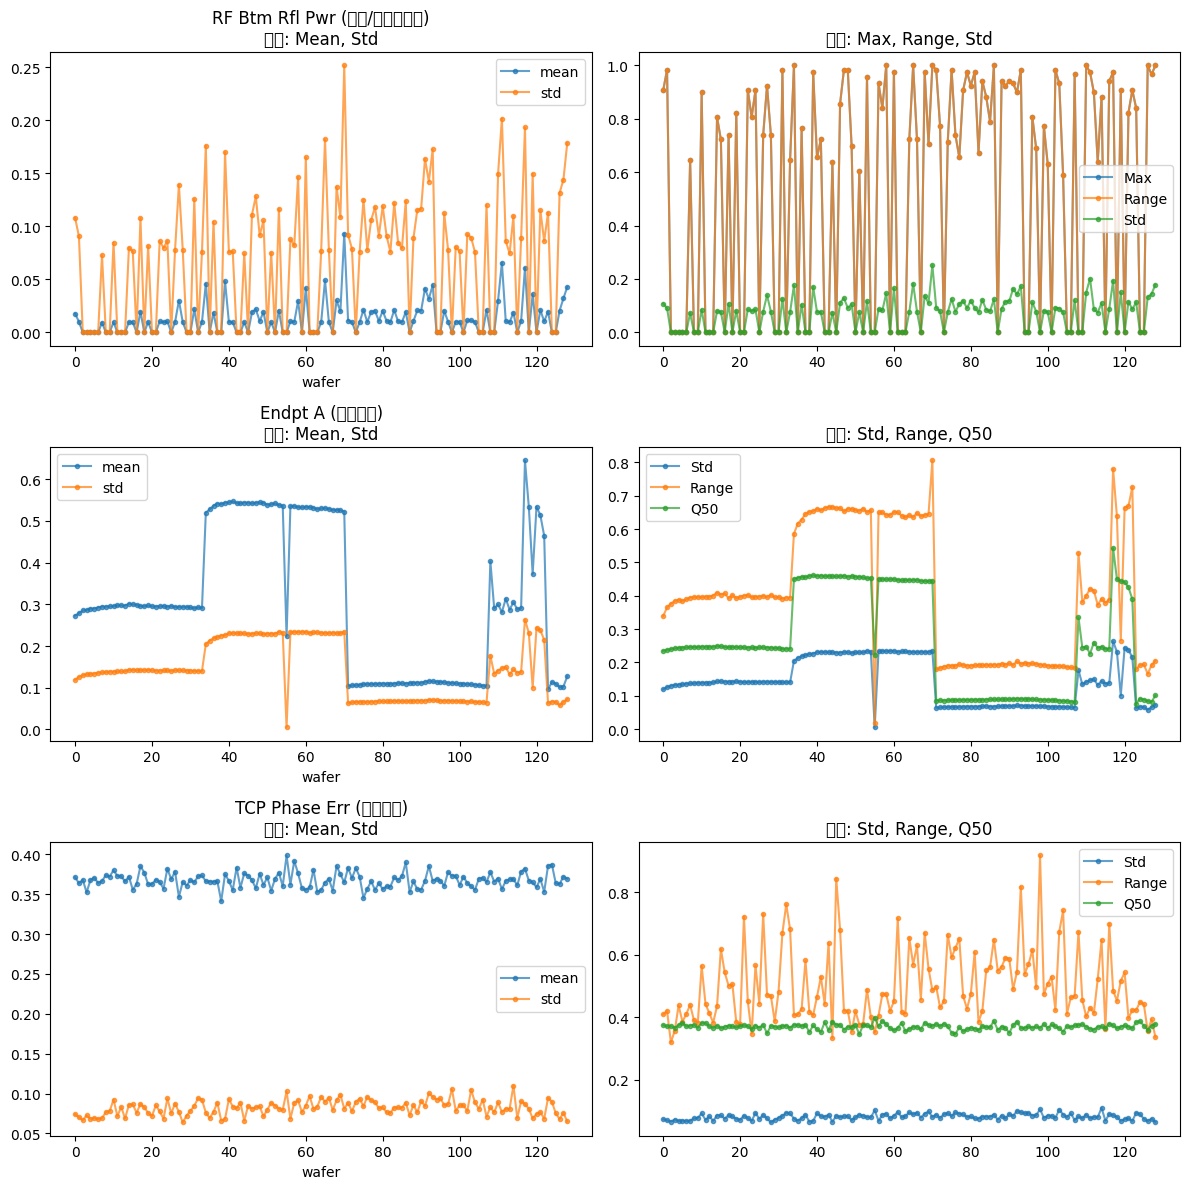

In [25]:
# 예: RF Btm Rfl Pwr — Mean은 거의 0, Max/Range가 spike 포착
compare_cols = ["RF Btm Rfl Pwr", "Endpt A", "TCP Phase Err"]

fig, axes = plt.subplots(len(compare_cols), 2, figsize=(12, 4 * len(compare_cols)))

for i, col in enumerate(compare_cols):
    dtype = profile_df.loc[profile_df["variable"] == col, "dist_type"].values[0]
    rec = stat_map[col]

    # 기존: Mean, Std
    old = data.groupby(level=0)[col].agg(["mean", "std"])
    old.plot(ax=axes[i, 0], marker="o", markersize=3, alpha=0.7)
    axes[i, 0].set_title(f"{col} ({dtype})\n기존: Mean, Std")
    axes[i, 0].set_xlabel("wafer")

    # 추천 통계량
    rec_df = pd.DataFrame({
        s: data.groupby(level=0)[col].apply(STAT_FUNCS[s]) for s in rec
    })
    rec_df.plot(ax=axes[i, 1], marker="o", markersize=3, alpha=0.7)
    axes[i, 1].set_title(f"추천: {', '.join(rec)}")

plt.tight_layout()
plt.show()